# 01 — Análise Exploratória de Dados

**Problema:** decidir se um pedido de cartão de crédito deve ser aprovado, estimando o risco de o cliente atrasar o pagamento em 60 dias ou mais.

**Dados:** duas tabelas. `application_record.csv` traz o formulário de solicitação (uma linha por conta). `credit_record.csv` traz o comportamento de pagamento mês a mês de cada conta.

Este notebook responde a quatro perguntas antes de qualquer modelagem: o que há nos dados, como definir o alvo, quais armadilhas a base esconde e o que isso implica para as etapas seguintes.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import json

from src.config import BAD_STATUS, GROUP, METRICS, RANDOM_STATE  # semente fixa: 42
from src.data import build_accounts, load_raw
from src.viz import AZUIS, AZUL, CINZA, LARANJA, save, set_style

set_style()
pd.set_option("display.max_columns", None)
print("RANDOM_STATE =", RANDOM_STATE)

RANDOM_STATE = 42


## 1. Visão geral

### Dicionário de variáveis

| Variável | Tipo | Descrição |
|---|---|---|
| `ID` | inteiro | identificador da conta |
| `CODE_GENDER` | categórica | gênero (F/M) |
| `FLAG_OWN_CAR`, `FLAG_OWN_REALTY` | binária | possui carro / imóvel |
| `CNT_CHILDREN`, `CNT_FAM_MEMBERS` | numérica | número de filhos / pessoas na família |
| `AMT_INCOME_TOTAL` | numérica | renda anual |
| `NAME_INCOME_TYPE` | categórica | origem da renda (assalariado, pensionista...) |
| `NAME_EDUCATION_TYPE` | categórica | escolaridade |
| `NAME_FAMILY_STATUS` | categórica | estado civil |
| `NAME_HOUSING_TYPE` | categórica | tipo de moradia |
| `DAYS_BIRTH` | numérica | dias desde o nascimento (negativo) |
| `DAYS_EMPLOYED` | numérica | dias desde o início do emprego atual (negativo); positivo = sem vínculo |
| `FLAG_MOBIL`, `FLAG_WORK_PHONE`, `FLAG_PHONE`, `FLAG_EMAIL` | binária | meios de contato informados |
| `OCCUPATION_TYPE` | categórica | ocupação |
| `MONTHS_BALANCE` | inteiro | mês do registro: 0 = mês da extração, -1 = mês anterior... |
| `STATUS` | categórica | situação no mês: `X` sem uso, `C` quitado, `0` atraso de 1-29 dias, `1` 30-59, `2` 60-89, `3` 90-119, `4` 120-149, `5` 150+ ou baixado como prejuízo |

In [2]:
app, credit = load_raw()

print(f"application_record: {app.shape[0]:,} linhas x {app.shape[1]} colunas")
print(f"credit_record:      {credit.shape[0]:,} linhas x {credit.shape[1]} colunas")
print(f"Contas no cadastro: {app['ID'].nunique():,} | contas com histórico: {credit['ID'].nunique():,} "
      f"| presentes nas duas tabelas: {len(set(app['ID']) & set(credit['ID'])):,}")
display(app.head(3))
display(credit.head(5))

application_record: 438,557 linhas x 18 colunas
credit_record:      1,048,575 linhas x 3 colunas


Contas no cadastro: 438,510 | contas com histórico: 45,985 | presentes nas duas tabelas: 36,457


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


O cadastro tem 438.557 linhas, mas só 36.457 contas aparecem também no histórico de pagamento: são elas que podem ser usadas, porque sem histórico não há como saber se a conta foi boa ou má. O histórico tem 1.048.575 registros mensais de 45.985 contas.

Um detalhe sobre a fonte: 1.048.575 registros mais o cabeçalho somam 1.048.576 linhas, exatamente o limite de linhas de uma planilha Excel. Isso sugere que o arquivo foi cortado na exportação, e que parte do histórico pode estar ausente. Não há como corrigir isso com os dados disponíveis; fica registrado como limitação.

In [3]:
base = build_accounts(app, credit)
print(f"Base de trabalho: {base.shape[0]:,} contas x {base.shape[1]} colunas")
base.info()

Base de trabalho: 36,457 contas x 23 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       36457 non-null  int64  
 1   CODE_GENDER              36457 non-null  object 
 2   FLAG_OWN_CAR             36457 non-null  object 
 3   FLAG_OWN_REALTY          36457 non-null  object 
 4   CNT_CHILDREN             36457 non-null  int64  
 5   AMT_INCOME_TOTAL         36457 non-null  float64
 6   NAME_INCOME_TYPE         36457 non-null  object 
 7   NAME_EDUCATION_TYPE      36457 non-null  object 
 8   NAME_FAMILY_STATUS       36457 non-null  object 
 9   NAME_HOUSING_TYPE        36457 non-null  object 
 10  DAYS_BIRTH               36457 non-null  int64  
 11  DAYS_EMPLOYED            36457 non-null  int64  
 12  FLAG_MOBIL               36457 non-null  int64  
 13  FLAG_WORK_PHONE          36457 

In [4]:
base.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5078227.00,41875.24,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
CNT_CHILDREN,36457.0,0.43,0.74,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,36457.0,186685.74,101789.23,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,36457.0,-15975.17,4200.55,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
DAYS_EMPLOYED,36457.0,59262.94,137651.33,-15713.0,-3153.0,-1552.0,-408.0,365243.0
FLAG_MOBIL,36457.0,1.00,0.00,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,36457.0,0.23,0.42,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,36457.0,0.29,0.46,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,36457.0,0.09,0.29,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,36457.0,2.20,0.91,1.0,2.0,2.0,3.0,20.0


`build_accounts` (em `src/data.py`) junta as duas tabelas em uma linha por conta e acrescenta o mês de abertura, o tempo de observação e o momento do primeiro atraso de 60 dias ou mais. Leituras iniciais:

- Só `OCCUPATION_TYPE` tem valores ausentes entre as variáveis originais.
- `DAYS_BIRTH` e `DAYS_EMPLOYED` são contagens negativas de dias, pouco legíveis: serão convertidas em anos.
- `DAYS_EMPLOYED` tem máximo de 365.243 dias (mil anos), um valor impossível, investigado na seção 4.
- `FLAG_MOBIL` vale 1 em todas as linhas: não carrega informação.
- As contas foram abertas entre 60 meses atrás e o mês da extração; em média, foram observadas por 26 meses.

### O mesmo proponente aparece várias vezes

Ao procurar linhas repetidas, encontramos contas com `ID` diferente e **todas** as 17 colunas de cadastro idênticas (mesma data de nascimento, mesma data de admissão, mesma renda, mesma ocupação...).

Contas: 36,457 | proponentes distintos: 9,728
Proponentes com mais de uma conta: 6,591 (68%), que concentram 91% das contas


,ID,DAYS_BIRTH,DAYS_EMPLOYED,AMT_INCOME_TOTAL,OCCUPATION_TYPE,MES_ABERTURA,target_qualquer_momento
32526,5137322,-22581,365243,36900.0,NaN,-41,0
32527,5137323,-22581,365243,36900.0,NaN,-48,0
32528,5137325,-22581,365243,36900.0,NaN,-24,0
32529,5137326,-22581,365243,36900.0,NaN,-48,0
32530,5137327,-22581,365243,36900.0,NaN,-46,0


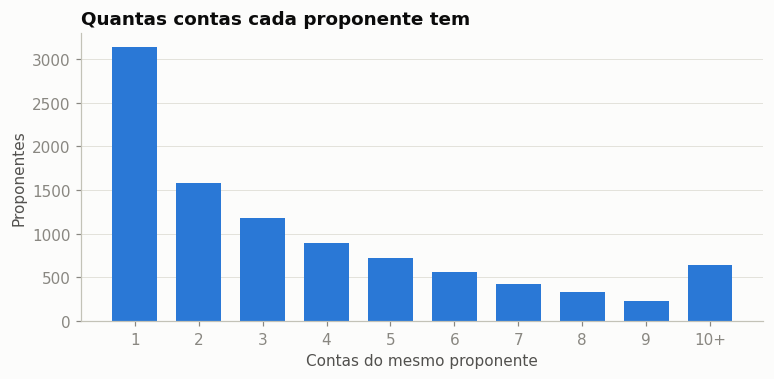

In [5]:
contas_por_proponente = base.groupby(GROUP).size()
print(f"Contas: {len(base):,} | proponentes distintos: {base[GROUP].nunique():,}")
print(f"Proponentes com mais de uma conta: {(contas_por_proponente > 1).sum():,} "
      f"({(contas_por_proponente > 1).mean():.0%}), que concentram "
      f"{contas_por_proponente[contas_por_proponente > 1].sum() / len(base):.0%} das contas")

exemplo = contas_por_proponente[contas_por_proponente == 5].index[0]
display(base.loc[base[GROUP] == exemplo,
                 ["ID", "DAYS_BIRTH", "DAYS_EMPLOYED", "AMT_INCOME_TOTAL", "OCCUPATION_TYPE",
                  "MES_ABERTURA", "target_qualquer_momento"]])

fig, ax = plt.subplots(figsize=(8, 3.4))
faixas = contas_por_proponente.clip(upper=10).value_counts().sort_index()
ax.bar([str(i) if i < 10 else "10+" for i in faixas.index], faixas.values, color=AZUL, width=0.7)
ax.set_title("Quantas contas cada proponente tem")
ax.set_xlabel("Contas do mesmo proponente")
ax.set_ylabel("Proponentes")
ax.grid(axis="x", visible=False)
save(fig, "01_contas_por_proponente")
plt.show()

As 36.457 contas correspondem a apenas 9.728 perfis cadastrais distintos. 68% deles têm mais de uma conta, e essas pessoas concentram 91% das contas. No exemplo acima, o mesmo perfil abriu cinco contas em meses diferentes.

A base não traz um identificador de pessoa. Assumimos que cadastros idênticos em todas as 17 colunas (incluindo data de nascimento e de admissão no emprego) são o mesmo **proponente**, e criamos a coluna `PROPONENTE` com essa chave. Isso tem duas consequências que orientam todo o projeto:

1. **Risco de vazamento.** Se as contas forem divididas ao acaso entre treino e teste, a mesma pessoa cai nos dois lados, e o modelo é avaliado em quem já conhece. O split e a validação cruzada precisam ser agrupados por proponente (notebook 03).
2. **Uma fonte de informação.** Quando alguém pede um novo cartão, o banco já sabe como essa pessoa pagou os cartões anteriores. Esse histórico interno vira variável no notebook 02.

## 2. Distribuição das variáveis

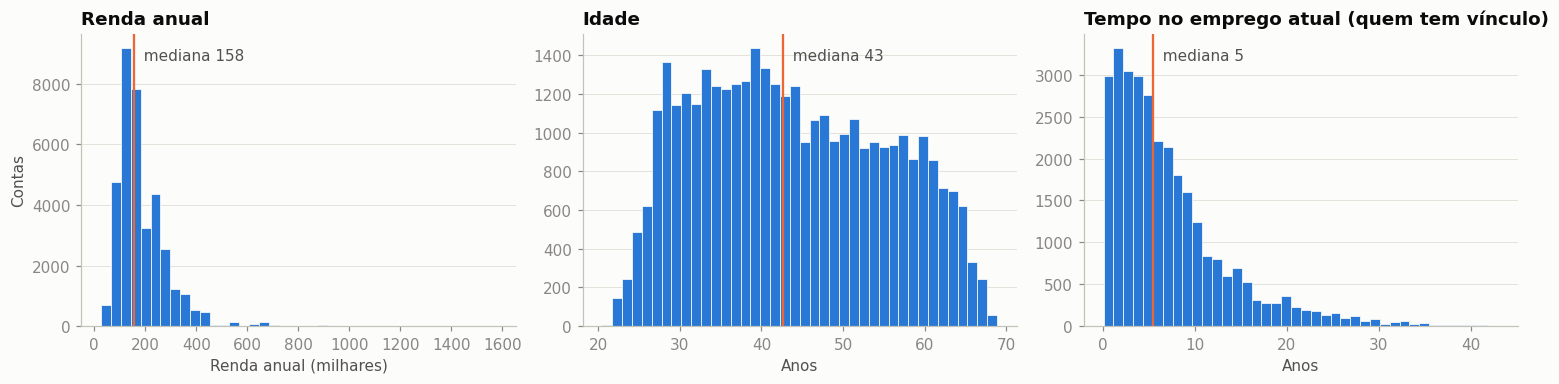

Assimetria (skew): {'renda': np.float64(2.74), 'idade': np.float64(0.18), 'tempo de emprego': np.float64(1.73)}


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
idade = -base["DAYS_BIRTH"] / 365.25
emprego = -base.loc[base["DAYS_EMPLOYED"] < 0, "DAYS_EMPLOYED"] / 365.25
for ax, serie, titulo, rotulo in [
    (axes[0], base["AMT_INCOME_TOTAL"] / 1000, "Renda anual", "Renda anual (milhares)"),
    (axes[1], idade, "Idade", "Anos"),
    (axes[2], emprego, "Tempo no emprego atual (quem tem vínculo)", "Anos"),
]:
    ax.hist(serie, bins=40, color=AZUL, edgecolor="#fcfcfb", linewidth=0.5)
    ax.axvline(serie.median(), color=LARANJA, linewidth=1.5)
    ax.text(serie.median(), ax.get_ylim()[1] * 0.95, f"  mediana {serie.median():.0f}", color="#52514e", va="top")
    ax.set_title(titulo)
    ax.set_xlabel(rotulo)
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("Contas")
plt.tight_layout()
save(fig, "01_distribuicoes")
plt.show()

print("Assimetria (skew):",
      {"renda": round(base["AMT_INCOME_TOTAL"].skew(), 2), "idade": round(idade.skew(), 2),
       "tempo de emprego": round(emprego.skew(), 2)})

A renda é fortemente assimétrica à direita (assimetria de 2,74): a maioria das contas está abaixo de 200 mil por ano e uma cauda longa passa de 1,5 milhão. A idade é quase simétrica (0,18), cobrindo dos 20 aos 69 anos. O tempo no emprego atual também é assimétrico (1,73): a maioria tem poucos anos de casa.

Implicação: modelos lineares são sensíveis a escalas tão diferentes (renda em centenas de milhares, idade em dezenas), então precisarão de padronização. Modelos de árvore não.

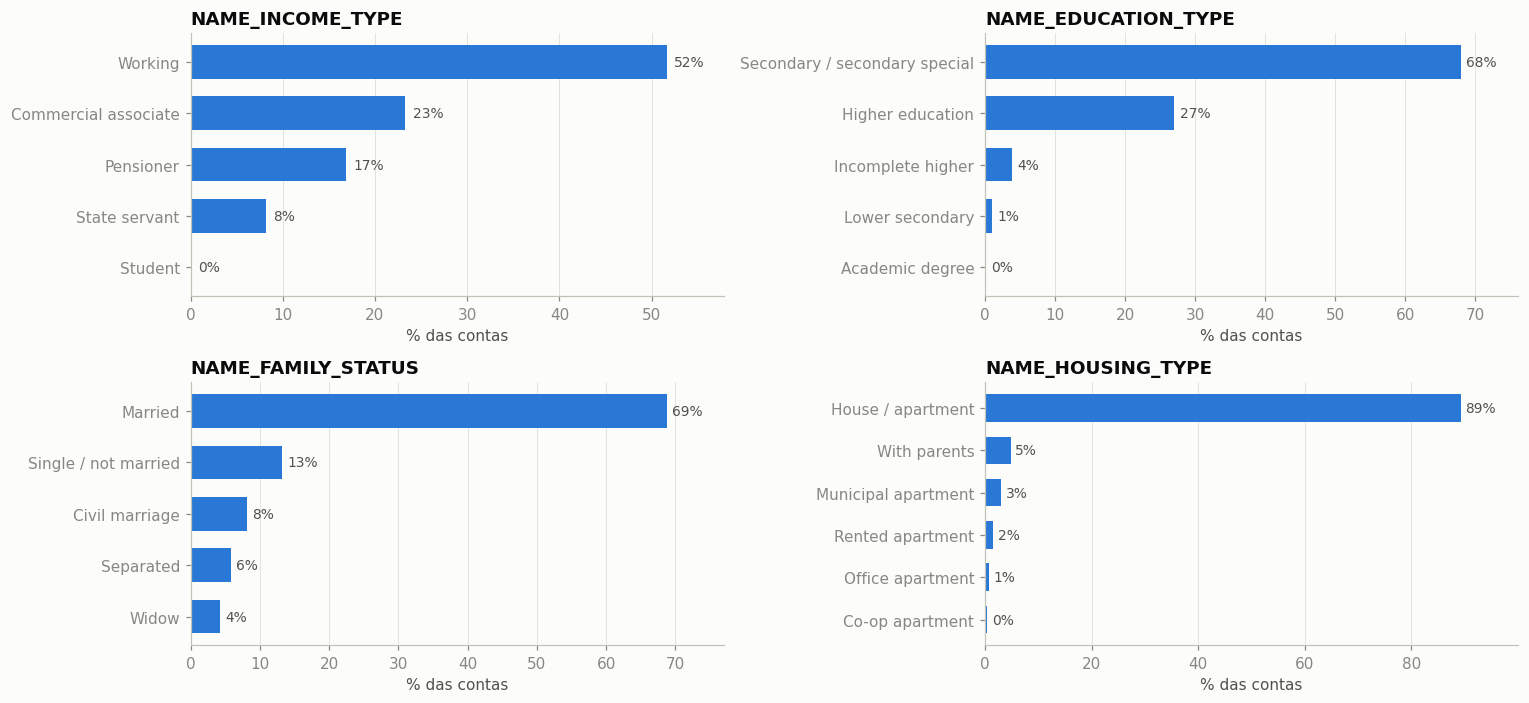

In [7]:
categoricas = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE"]
fig, axes = plt.subplots(2, 2, figsize=(14, 6.5))
for ax, col in zip(axes.ravel(), categoricas):
    pct = base[col].value_counts(normalize=True).sort_values() * 100
    ax.barh(pct.index, pct.values, color=AZUL, height=0.65)
    for y, v in enumerate(pct.values):
        ax.text(v + 0.8, y, f"{v:.0f}%", va="center", color="#52514e", fontsize=9)
    ax.set_title(col)
    ax.set_xlabel("% das contas")
    ax.set_xlim(0, pct.max() * 1.12)
    ax.grid(axis="y", visible=False)
plt.tight_layout()
save(fig, "01_categoricas")
plt.show()

A carteira é homogênea: 52% são assalariados (`Working`), 68% têm ensino médio, 69% são casados e 89% moram em casa ou apartamento próprio. Algumas categorias são muito raras (`Student`, `Academic degree`, `Co-op apartment`, todas abaixo de 1%). Com tão poucos casos, o modelo não tem como aprender nada confiável sobre elas; o one-hot encoding as mantém, mas com `handle_unknown="ignore"` para o caso de uma categoria não aparecer em algum fold.

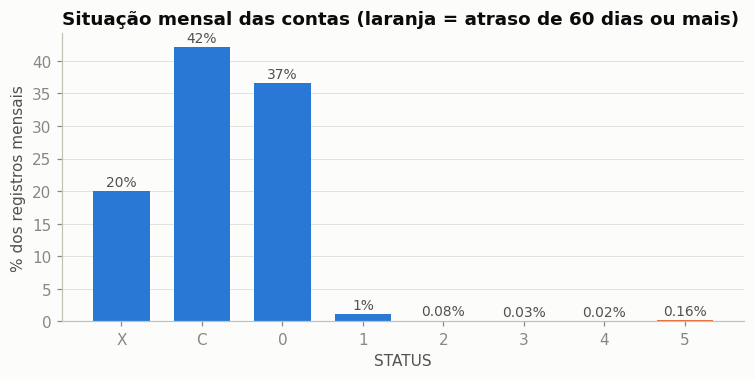

Registros mensais com atraso 60+: 0.30%


In [8]:
status = credit["STATUS"].value_counts(normalize=True).reindex(["X", "C", "0", "1", "2", "3", "4", "5"]) * 100
fig, ax = plt.subplots(figsize=(8, 3.4))
cores = [LARANJA if s in BAD_STATUS else AZUL for s in status.index]
ax.bar(status.index, status.values, color=cores, width=0.7)
for x, v in enumerate(status.values):
    ax.text(x, v + 0.8, f"{v:.2f}%" if v < 1 else f"{v:.0f}%", ha="center", color="#52514e", fontsize=9)
ax.set_title("Situação mensal das contas (laranja = atraso de 60 dias ou mais)")
ax.set_xlabel("STATUS")
ax.set_ylabel("% dos registros mensais")
ax.grid(axis="x", visible=False)
save(fig, "01_status")
plt.show()
print(f"Registros mensais com atraso 60+: {credit['STATUS'].isin(BAD_STATUS).mean():.2%}")

Em 62% dos meses a conta está quitada (`C`) ou sem uso (`X`). Atrasos de até 29 dias (`0`) são comuns, 37% dos registros, e por isso não servem para definir um mau pagador: marcariam quase todo mundo. Atrasos de 30 a 59 dias são 1%. Atrasos de 60 dias ou mais (`2` a `5`) somam apenas 0,30% dos registros mensais.

Adotamos **60 dias ou mais** como definição de atraso grave: é onde o comportamento deixa de ser esquecimento e passa a ser inadimplência, e ainda há casos suficientes para aprender. O critério de 90 dias, usado em regulação bancária, deixaria ainda menos exemplos.

## 3. Correlações

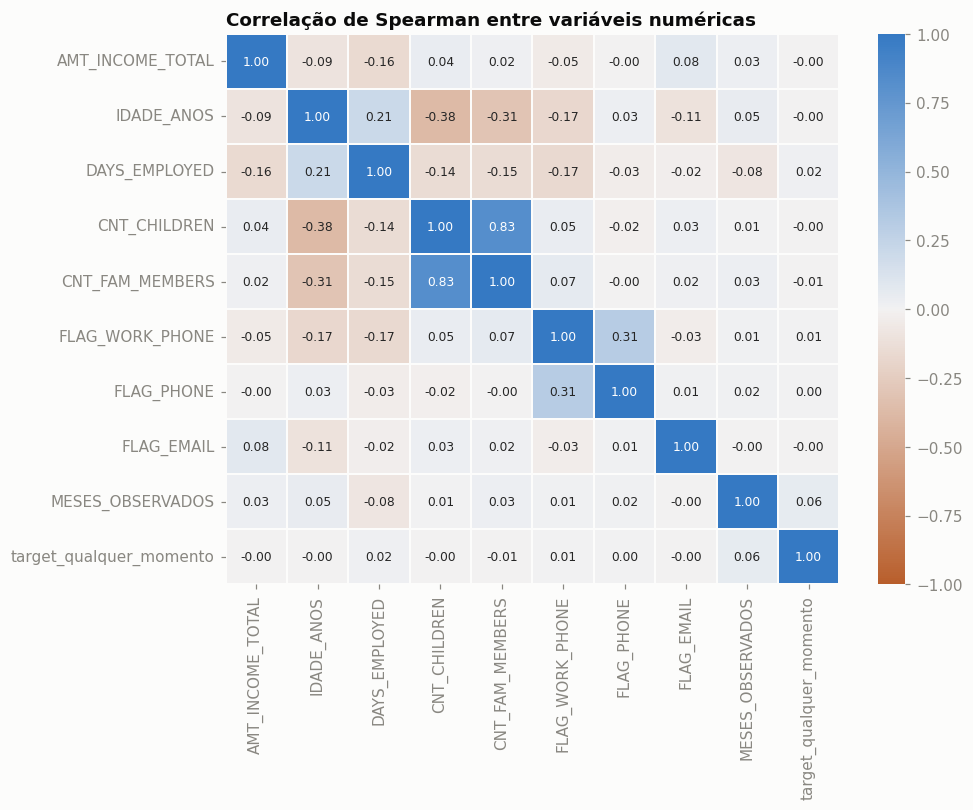

Correlação com o atraso 60+ (qualquer momento):
MESES_OBSERVADOS    0.060
DAYS_EMPLOYED       0.022
CNT_FAM_MEMBERS    -0.008
FLAG_WORK_PHONE     0.006
FLAG_EMAIL         -0.002
IDADE_ANOS         -0.002
CNT_CHILDREN       -0.002
FLAG_PHONE          0.002
AMT_INCOME_TOTAL   -0.001


In [9]:
numericas = base.assign(IDADE_ANOS=idade)[
    ["AMT_INCOME_TOTAL", "IDADE_ANOS", "DAYS_EMPLOYED", "CNT_CHILDREN", "CNT_FAM_MEMBERS",
     "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL", "MESES_OBSERVADOS", "target_qualquer_momento"]
]
corr = numericas.corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=sns.diverging_palette(28, 250, s=85, l=50, as_cmap=True),
            center=0, vmin=-1, vmax=1, linewidths=1, linecolor="#fcfcfb", annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlação de Spearman entre variáveis numéricas")
ax.grid(False)
save(fig, "01_correlacao")
plt.show()

print("Correlação com o atraso 60+ (qualquer momento):")
print(corr["target_qualquer_momento"].drop("target_qualquer_momento").sort_values(key=abs, ascending=False).round(3).to_string())

- `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,83): quase a mesma informação, o que é esperado, já que filhos fazem parte da família.
- Idade e número de filhos (-0,38) e idade e tamanho da família (-0,31): clientes mais velhos têm menos dependentes em casa.
- `FLAG_WORK_PHONE` e `FLAG_PHONE` (0,31): quem informa um telefone tende a informar o outro.
- Idade e `DAYS_EMPLOYED` (0,21): efeito do código 365243 dos pensionistas, que são mais velhos (seção 4).
- **Com o atraso grave, nenhuma variável do formulário passa de 0,02 em módulo.** Renda, idade e família praticamente não se relacionam com o alvo.
- A maior correlação com o alvo é a de `MESES_OBSERVADOS` (0,06), que não é uma característica do cliente, e sim do tempo em que a conta ficou sob observação. A seção 5 mostra por que isso é um problema.

## 4. Outliers

DAYS_EMPLOYED = 365243: 6,135 contas (16.8%)
Origem da renda dessas contas: {'Pensioner': 6135}

Renda acima de Q3 + 1,5 IQR (380,250): 4.2% das contas; máximo 1,575,000
CNT_CHILDREN acima de 5: 6 contas; máximo 19


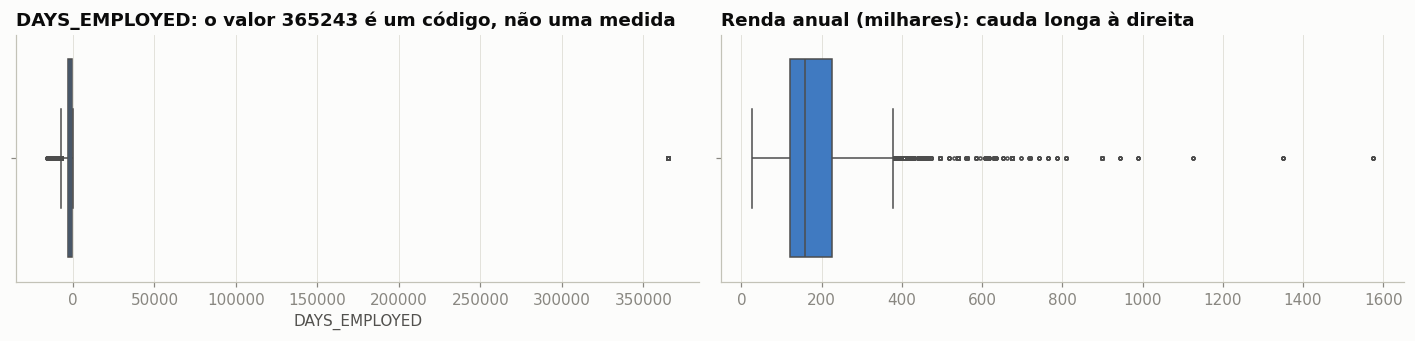

In [10]:
sentinela = base["DAYS_EMPLOYED"].max()
com_sentinela = base["DAYS_EMPLOYED"] == sentinela
print(f"DAYS_EMPLOYED = {sentinela}: {com_sentinela.sum():,} contas ({com_sentinela.mean():.1%})")
print("Origem da renda dessas contas:", base.loc[com_sentinela, "NAME_INCOME_TYPE"].value_counts().to_dict())

q1, q3 = base["AMT_INCOME_TOTAL"].quantile([0.25, 0.75])
limite = q3 + 1.5 * (q3 - q1)
print(f"\nRenda acima de Q3 + 1,5 IQR ({limite:,.0f}): {(base['AMT_INCOME_TOTAL'] > limite).mean():.1%} das contas; "
      f"máximo {base['AMT_INCOME_TOTAL'].max():,.0f}")
print(f"CNT_CHILDREN acima de 5: {(base['CNT_CHILDREN'] > 5).sum()} contas; máximo {base['CNT_CHILDREN'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
sns.boxplot(x=base["DAYS_EMPLOYED"], color=AZUL, fliersize=2, linewidth=1, ax=axes[0])
axes[0].set_title("DAYS_EMPLOYED: o valor 365243 é um código, não uma medida")
sns.boxplot(x=base["AMT_INCOME_TOTAL"] / 1000, color=AZUL, fliersize=2, linewidth=1, ax=axes[1])
axes[1].set_title("Renda anual (milhares): cauda longa à direita")
axes[1].set_xlabel("")
plt.tight_layout()
save(fig, "01_outliers")
plt.show()

- **`DAYS_EMPLOYED` = 365243** em 6.135 contas (16,8%), todas de pensionistas. É um código para "sem vínculo empregatício", não uma medida. **Decisão:** criar o indicador `SEM_VINCULO` e registrar zero anos de emprego, em vez de remover 17% da base ou deixar um valor de mil anos distorcer os modelos.
- **Renda:** 4,2% das contas estão acima do limite de Q3 + 1,5 IQR, com máximo de 1,575 milhão. São valores altos, mas plausíveis. **Decisão:** manter. Remover clientes de alta renda enviesaria a carteira, e a padronização dentro do pipeline cuida da escala.
- **`CNT_CHILDREN`:** 6 contas com mais de 5 filhos (máximo 19). Possível erro de digitação, mas são 6 linhas em 36 mil. **Decisão:** manter; o efeito é desprezível.

## 5. Balanceamento de classes e definição do alvo

A base não traz uma coluna "bom/mau pagador": ela precisa ser construída a partir do `STATUS`. A primeira ideia é marcar como mau quem atingiu atraso de 60 dias ou mais em **qualquer** mês observado.

In [11]:
taxa = base["target_qualquer_momento"].mean()
print(f"Contas com atraso 60+ em algum momento: {base['target_qualquer_momento'].sum()} de {len(base):,} ({taxa:.2%})")
print(f"Um modelo que aprovasse todo mundo teria {1 - taxa:.1%} de acurácia.")

Contas com atraso 60+ em algum momento: 616 de 36,457 (1.69%)
Um modelo que aprovasse todo mundo teria 98.3% de acurácia.


Só 1,69% das contas registram atraso grave. Com esse desbalanceamento, a acurácia não serve como métrica: aprovar todos os pedidos acerta 98,3% das vezes sem evitar um único calote. As métricas adequadas medem a capacidade de separar as duas classes (ROC-AUC, PR-AUC) e o equilíbrio entre os tipos de erro (MCC, F1, precisão e recall).

Antes de aceitar essa definição de alvo, porém, verificamos se ela é justa com todas as contas.

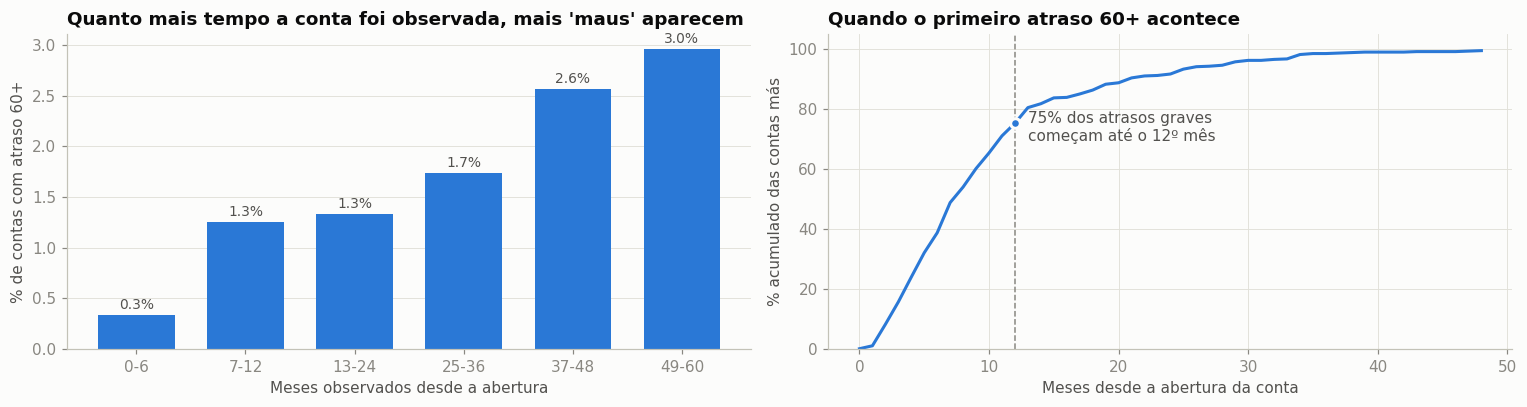

,contas,taxa_atraso_60
MESES_OBSERVADOS,,
0-6,4714,0.0034
7-12,4876,0.0125
13-24,8720,0.0133
25-36,7309,0.0174
37-48,6308,0.0257
49-60,4530,0.0296


Meses até o primeiro atraso 60+ — quartis: [5.0, 8.0, 12.0]
Contas observadas por 12 meses ou mais: 76%


226

In [12]:
faixas = pd.cut(base["MESES_OBSERVADOS"], [-1, 6, 12, 24, 36, 48, 61],
                labels=["0-6", "7-12", "13-24", "25-36", "37-48", "49-60"])
por_faixa = base.groupby(faixas, observed=True)["target_qualquer_momento"].agg(["size", "mean"])

maus = base["MES_PRIMEIRO_ATRASO"].dropna()
acumulado = pd.Series({m: (maus <= m).mean() for m in range(0, 49)})

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].bar(por_faixa.index.astype(str), por_faixa["mean"] * 100, color=AZUL, width=0.7)
for x, v in enumerate(por_faixa["mean"] * 100):
    axes[0].text(x, v + 0.06, f"{v:.1f}%", ha="center", color="#52514e", fontsize=9)
axes[0].set_title("Quanto mais tempo a conta foi observada, mais 'maus' aparecem")
axes[0].set_xlabel("Meses observados desde a abertura")
axes[0].set_ylabel("% de contas com atraso 60+")
axes[0].grid(axis="x", visible=False)

axes[1].plot(acumulado.index, acumulado.values * 100, color=AZUL)
axes[1].axvline(12, color=CINZA, linewidth=1, linestyle="--")
axes[1].scatter([12], [acumulado[12] * 100], color=AZUL, s=40, zorder=3, edgecolor="#fcfcfb", linewidth=2)
axes[1].text(13, acumulado[12] * 100 - 6, f"{acumulado[12]:.0%} dos atrasos graves\ncomeçam até o 12º mês", color="#52514e")
axes[1].set_title("Quando o primeiro atraso 60+ acontece")
axes[1].set_xlabel("Meses desde a abertura da conta")
axes[1].set_ylabel("% acumulado das contas más")
axes[1].set_ylim(0, 105)
plt.tight_layout()
save(fig, "01_exposicao")
plt.show()

display(por_faixa.rename(columns={"size": "contas", "mean": "taxa_atraso_60"}).round(4))
print("Meses até o primeiro atraso 60+ — quartis:", maus.quantile([0.25, 0.5, 0.75]).tolist())
print(f"Contas observadas por 12 meses ou mais: {(base['MESES_OBSERVADOS'] >= 12).mean():.0%}")

METRICS.mkdir(parents=True, exist_ok=True)
(METRICS / "resumo_eda.json").write_text(json.dumps({
    "contas": int(len(base)),
    "proponentes": int(base[GROUP].nunique()),
    "pct_proponentes_com_mais_de_uma_conta": round(float((contas_por_proponente > 1).mean()), 4),
    "pct_contas_de_proponentes_repetidos": round(float(contas_por_proponente[contas_por_proponente > 1].sum() / len(base)), 4),
    "taxa_atraso_60_qualquer_momento": round(float(taxa), 4),
    "pct_atrasos_ate_12_meses": round(float(acumulado[12]), 4),
}, indent=2))

**A definição "atraso em qualquer momento" é enviesada.** À esquerda: contas observadas por até 6 meses têm 0,3% de atraso grave; contas observadas por mais de 4 anos têm 3,0%. Não é que clientes antigos sejam piores: eles apenas tiveram mais tempo para atrasar. Uma conta aberta há dois meses e rotulada como "boa" ainda não teve a chance de mostrar o que é.

Esse viés contamina o modelo de duas formas. Rotula como bons clientes que ainda não foram testados, e faz com que qualquer variável ligada à data de abertura pareça preditiva, sem ser uma característica que o banco conheça no momento do pedido.

À direita está a solução. Entre as contas más, metade tem o primeiro atraso grave até o 8º mês e 75% até o 12º. **Decisão:** o alvo passa a ser *atraso de 60 dias ou mais nos primeiros 12 meses de conta*, calculado apenas para contas com pelo menos 12 meses de observação (76% da base). Assim todas são medidas pela mesma régua.

## 6. Síntese da EDA

1. **Só 36.457 contas servem para modelagem** (as que têm cadastro e histórico), e o arquivo de histórico parece truncado.
2. **Uma pessoa, várias contas.** São 9.728 proponentes distintos. Isso obriga a separar treino e teste por pessoa e abre a possibilidade de usar o histórico interno do cliente.
3. **O alvo precisa de uma janela fixa.** Atraso de 60+ dias nos primeiros 12 meses, só para contas com 12 meses de observação.
4. **O evento é raro** (menos de 2%), então acurácia não é métrica.
5. **O formulário, sozinho, promete pouco.** Nenhuma variável cadastral tem correlação relevante com o atraso grave.
6. **Tratamentos necessários:** código 365243 em `DAYS_EMPLOYED`, ocupação ausente em 31% das contas, `FLAG_MOBIL` constante, conversão de dias em anos e padronização para modelos lineares.

A história que emerge para a apresentação: o risco de um novo cartão não está no que o cliente declara, e sim em como ele já se comportou.